=== 1. LOADING VALIDATED DATASETS ===
Cleaned Dataset Shape: (5000, 20)
Validated Feature Matrix Shape: (5000, 22)

=== 2. FINAL EXECUTIVE KPIS ===
Total Appointments Evaluated: 5,000
Total Patient No-Shows: 2,423
Final Baseline No-Show Rate: 48.46%

Attendance Rate by Reminder Channel (%):
reminder_channel  Attendance_Rate
           Email        46.529081
No Reminder Sent        42.679356
             SMS        49.600000
        WhatsApp        44.595822

Mean Booking Lead Time by Outcome (Days):
appointment_outcome  booking_lead_days
           Attended          24.521175
          Cancelled          29.631179
            No-Show          34.526620

=== 3. GENERATING EXECUTIVE DASHBOARD CHARTS ===


C:\Users\Brian\AppData\Local\Temp\ipykernel_16156\1907392880.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_perf, x='reminder_channel', y='Attendance_Rate', ax=axes[0,0], palette='Blues_r')
C:\Users\Brian\AppData\Local\Temp\ipykernel_16156\1907392880.py:77: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cleaned, x='appointment_outcome', y='booking_lead_days', ax=axes[0,1], palette='Set2')
C:\Users\Brian\AppData\Local\Temp\ipykernel_16156\1907392880.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bracket_no

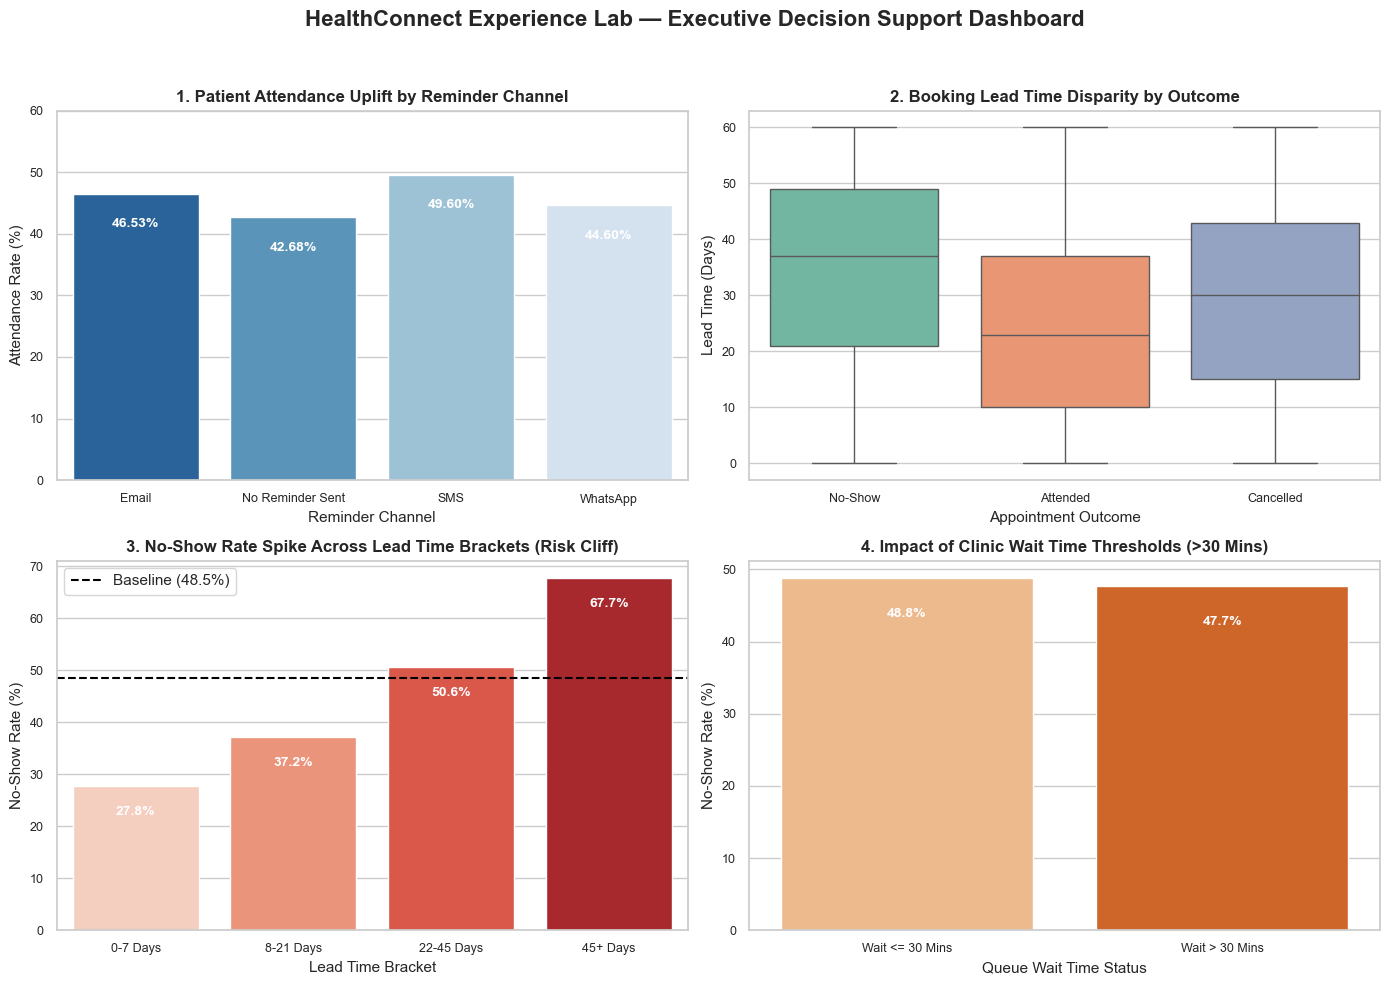

Dashboard image saved as: HealthConnect_Week8_Executive_Dashboard.png


In [1]:
# ==============================================================================
# HealthConnect Clinic Analytics - Week 8
# Final Integration, Executive Visualization & Decision Support Package
# Author: Brian Kariuki | Data Analytics Track
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual styling for executive presentation
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.titlesize': 14
})

# ------------------------------------------------------------------------------
# 1. LOAD VALIDATED DATASETS
# ------------------------------------------------------------------------------
print("=== 1. LOADING VALIDATED DATASETS ===")
df_cleaned = pd.read_csv("HealthConnect_Appointment_Data_Cleaned.csv")
df_validated = pd.read_csv("HealthConnect_Feature_Engineered_Segments_Validated.csv")

print(f"Cleaned Dataset Shape: {df_cleaned.shape}")
print(f"Validated Feature Matrix Shape: {df_validated.shape}")

# ------------------------------------------------------------------------------
# 2. FINAL KPI CONSOLIDATION
# ------------------------------------------------------------------------------
print("\n=== 2. FINAL EXECUTIVE KPIS ===")
total_appts = len(df_cleaned)
total_noshows = (df_cleaned['appointment_outcome'] == 'No-Show').sum()
noshow_rate = (total_noshows / total_appts) * 100

print(f"Total Appointments Evaluated: {total_appts:,}")
print(f"Total Patient No-Shows: {total_noshows:,}")
print(f"Final Baseline No-Show Rate: {noshow_rate:.2f}%")

# Reminder Channel Attendance Metrics
channel_perf = df_cleaned.groupby('reminder_channel')['appointment_outcome'].apply(
    lambda x: (x == 'Attended').mean() * 100
).reset_index(name='Attendance_Rate')

print("\nAttendance Rate by Reminder Channel (%):")
print(channel_perf.to_string(index=False))

# Lead Time Cohort Comparison
lead_summary = df_cleaned.groupby('appointment_outcome')['booking_lead_days'].mean().reset_index()
print("\nMean Booking Lead Time by Outcome (Days):")
print(lead_summary.to_string(index=False))

# ------------------------------------------------------------------------------
# 3. EXECUTIVE DASHBOARD VISUALIZATIONS
# ------------------------------------------------------------------------------
print("\n=== 3. GENERATING EXECUTIVE DASHBOARD CHARTS ===")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("HealthConnect Experience Lab — Executive Decision Support Dashboard", fontsize=16, fontweight='bold', y=0.98)

# Chart 1: Attendance Rate by Communication Channel
sns.barplot(data=channel_perf, x='reminder_channel', y='Attendance_Rate', ax=axes[0,0], palette='Blues_r')
axes[0,0].set_title("1. Patient Attendance Uplift by Reminder Channel", fontweight='bold')
axes[0,0].set_xlabel("Reminder Channel")
axes[0,0].set_ylabel("Attendance Rate (%)")
axes[0,0].set_ylim(0, 60)
for p in axes[0,0].patches:
    axes[0,0].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 5),
                       ha='center', va='center', color='white', fontweight='bold')

# Chart 2: Booking Lead Time Risk Distribution
sns.boxplot(data=df_cleaned, x='appointment_outcome', y='booking_lead_days', ax=axes[0,1], palette='Set2')
axes[0,1].set_title("2. Booking Lead Time Disparity by Outcome", fontweight='bold')
axes[0,1].set_xlabel("Appointment Outcome")
axes[0,1].set_ylabel("Lead Time (Days)")

# Chart 3: Non-Linear Lead Time Risk Cliff (>21 Days)
lead_bracket_order = ['0-7 Days', '8-21 Days', '22-45 Days', '45+ Days']
bracket_noshow = df_validated.groupby('lead_time_bracket')['appointment_outcome'].apply(
    lambda x: (x == 'No-Show').mean() * 100
).reindex(lead_bracket_order).reset_index()

sns.barplot(data=bracket_noshow, x='lead_time_bracket', y='appointment_outcome', ax=axes[1,0], palette='Reds')
axes[1,0].set_title("3. No-Show Rate Spike Across Lead Time Brackets (Risk Cliff)", fontweight='bold')
axes[1,0].set_xlabel("Lead Time Bracket")
axes[1,0].set_ylabel("No-Show Rate (%)")
axes[1,0].axhline(noshow_rate, color='black', linestyle='--', label=f'Baseline ({noshow_rate:.1f}%)')
axes[1,0].legend()
for p in axes[1,0].patches:
    axes[1,0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 5),
                       ha='center', va='center', color='white', fontweight='bold')

# Chart 4: Queue Wait Time Flag Impact
wait_impact = df_validated.groupby('high_wait_flag')['appointment_outcome'].apply(
    lambda x: (x == 'No-Show').mean() * 100
).reset_index()
wait_impact['high_wait_flag'] = wait_impact['high_wait_flag'].map({0: 'Wait <= 30 Mins', 1: 'Wait > 30 Mins'})

sns.barplot(data=wait_impact, x='high_wait_flag', y='appointment_outcome', ax=axes[1,1], palette='Oranges')
axes[1,1].set_title("4. Impact of Clinic Wait Time Thresholds (>30 Mins)", fontweight='bold')
axes[1,1].set_xlabel("Queue Wait Time Status")
axes[1,1].set_ylabel("No-Show Rate (%)")
for p in axes[1,1].patches:
    axes[1,1].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() - 5),
                       ha='center', va='center', color='white', fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("HealthConnect_Week8_Executive_Dashboard.png", dpi=300)
plt.show()

print("Dashboard image saved as: HealthConnect_Week8_Executive_Dashboard.png")